<h1 style="color:blue;">BANK CUSTOMER CHURN ANALYSIS</h1>


<div style="background-color:#D6F7B7; padding:10px; border-radius:5px;">
<b>Project Overview </b> 

This project analyzes a Bank Customer Churn dataset to understand the factors influencing customer attrition. 

<b>Business Problem</b>

Banks lose revenue when customers leave. By predicting churn, banks can:
- Retain valuable customers
- Improve services
- Reduce marketing costs
- Increase customer satisfaction
<b>The notebook includes:</b>

- Data loading and preprocessing
- Exploratory Data Analysis (EDA)
- Data visualization
- Key business insights
- Customer churn pattern analysis
</div>


<h2 style="color:darkblue;">1. Data Loading and Initial Overview</h2> 

<h3 style="color:darkgreen;">1.1 Import Required Libraries</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

<h3 style="color:darkgreen;">1.2 Load the Dataset</h3>

In [2]:
file_path = r'C:\Users\revat\OneDrive\Desktop\Assignments\Main Project\Bank_Churn.csv'
df = pd.read_csv(file_path)

<h3 style="color:darkgreen;">1.3 Dataset Information</h3> 

<h4 style="color:purple;">Check number of Rows and Columns</h4>

In [3]:
print("Rows:", df.shape[0])

print("Columns:", df.shape[1])

Rows: 10000
Columns: 13


<h4 style="color:purple;">Check Data types of each Column</h4>

In [4]:
print(df.dtypes)

CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


<h4 style="color:purple;">Display First 5 Rows</h4>

In [5]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<h4 style="color:purple;">Dataset Overall Information</h4>

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  str    
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 1015.8 KB


<h4 style="color:purple;">Statistical summary</h4>

In [7]:
round(df.describe(),3)

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,1.569094e+07,650.529,38.922,5.013,76485.889,1.530,0.706,0.515,100090.240,0.204
std,7.193619e+04,96.653,10.488,2.892,62397.405,0.582,0.456,0.500,57510.493,0.403
min,1.556570e+07,350.000,18.000,0.000,0.000,1.000,0.000,0.000,11.580,0.000
25%,1.562853e+07,584.000,32.000,3.000,0.000,1.000,0.000,0.000,51002.110,0.000
50%,1.569074e+07,652.000,37.000,5.000,97198.540,1.000,1.000,1.000,100193.915,0.000
75%,1.575323e+07,718.000,44.000,7.000,127644.240,2.000,1.000,1.000,149388.248,0.000
max,1.581569e+07,850.000,92.000,10.000,250898.090,4.000,1.000,1.000,199992.480,1.000


<h2 style="color:darkblue;">2. Data Pre-processing </h2> 

<h3 style="color:darkgreen;">2.1 Check Missing Values</h3>

In [8]:
# Find Missing values
df.isna().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

<h3 style="color:darkgreen;">2.2 Remove Duplicates</h3>

In [9]:
# Check duplicate rows
print('Duplicate Rows Before Removal:', df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

print('Duplicate Rows After Removal:', df.duplicated().sum())

Duplicate Rows Before Removal: 0
Duplicate Rows After Removal: 0


<h3 style="color:darkgreen;">2.3 Data Formatting</h3>

In [10]:
# Convert column names to lowercase
df.columns = df.columns.str.lower()

# Display updated column names
print(df.columns)

Index(['customerid', 'surname', 'creditscore', 'geography', 'gender', 'age',
       'tenure', 'balance', 'numofproducts', 'hascrcard', 'isactivemember',
       'estimatedsalary', 'exited'],
      dtype='str')


<h3 style="color:darkgreen;">2.4 Creating Derived Columns </h3>

In [11]:
# Create age group feature
bins = [18, 30, 40, 50, 60, 100]
labels = ['18-30', '31-40', '41-50', '51-60', '60+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Create balance category feature

df['balance_category'] = np.where(df['balance'] > df['balance'].median(),
                                  'High Balance',
                                  'Low Balance')
df.head()

,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,age_group,balance_category
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50,Low Balance
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-50,Low Balance
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50,High Balance
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,31-40,Low Balance
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-50,High Balance


<h3 style="color:darkgreen;">2.5 Filtering and aggregating data</h3>

<h4 style="color:purple;">Filter customers who exited</h4>

In [12]:
exited_customers = df[df['exited'] == 1]

exited_customers.head()

,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,age_group,balance_category
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50,Low Balance
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50,High Balance
5,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,41-50,High Balance
7,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,18-30,High Balance
16,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1,51-60,High Balance


<h4 style="color:purple;">Filter Customers older than 40</h4>

In [13]:
age_filter = df[df['age'] > 40]

age_filter.head()

,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,age_group,balance_category
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-50,Low Balance
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,41-50,Low Balance
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-50,High Balance
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-50,High Balance
5,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,41-50,High Balance


<h4 style="color:purple;">Average balance</h4>

In [14]:
print(df['balance'].mean())

76485.889288


<h4 style="color:purple;">Highest salary</h4>

In [15]:
print(df['estimatedsalary'].max())

199992.48


<h2 style="color:darkblue;">3. Exploratory Data Analysis</h2> 

<h4 style="color:purple;">Computing the number of exited and not exited clients</h4>

In [16]:
exited = len(df[df['exited'] == 1]['exited'])
not_exited = len(df[df['exited'] == 0]['exited'])
exited_perc = round(exited/len(df)*100,1)
not_exited_perc = round(not_exited/len(df)*100,1)

print('Number of clients that have exited the program: {} ({}%)'.format(exited, exited_perc))
print('Number of clients that haven\'t exited the program: {} ({}%)'.format(not_exited, not_exited_perc))

Number of clients that have exited the program: 2037 (20.4%)
Number of clients that haven't exited the program: 7963 (79.6%)


<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> So, around of 20% of the clients exited the bank, while around 80% stayed.
</div>

<h4 style="color:purple;">Check Unique Geography and Gender</h4>

In [17]:
country = list(df['geography'].unique())
gender = list(df['gender'].unique())

print(country)
print(gender)

['France', 'Spain', 'Germany']
['Female', 'Male']


<h4 style="color:purple;">Gender distribution</h4>

In [18]:
gender_count = df['gender'].value_counts()
gender_pct= gender_count / len(df.index)

gender = pd.concat([gender_count, round(gender_pct,2)], axis=1)\
        .set_axis(['count', 'pct'], axis=1)
gender.index.name = None
gender

,count,pct
Male,5457,0.55
Female,4543,0.45


<h4 style="color:purple;">Geography distribution</h4>

In [19]:
geo_count = df['geography'].value_counts()
geo_pct= geo_count / len(df.index)

geo = pd.concat([geo_count, round(geo_pct,2)], axis=1)\
        .set_axis(['count', 'pct'], axis=1)
geo.index.name = None
geo

,count,pct
France,5014,0.50
Germany,2509,0.25
Spain,2477,0.25


<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> In the dataset, there are more men (55%) than women (45%), and it has only 3 different countries: France, Spain, and Germany. Where 50% of the customers are from France and 25% are from Germany, and the other group are from Spain.
</div>

<h4 style="color:purple;">Check the relationship between the features and the outcome ('Exited')</h4>

In [20]:
def count_by_group(data, feature, target):
    df = data.groupby([feature, target])[target].agg(['count'])
    temp = data.groupby([feature])[target].agg(['count'])
    df['pct'] = 100*df.div(temp, level = feature).reset_index()['count'].values
    return df.reset_index()
count_by_group(df, feature = 'gender', target = 'exited')

,gender,exited,count,pct
0,Female,0,3404,74.928461
1,Female,1,1139,25.071539
2,Male,0,4559,83.544072
3,Male,1,898,16.455928


<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> As for gender, women are lower in number than the men, but have a higher rate to close the account
</div>

In [21]:
count_by_group(df, feature = 'geography', target = 'exited')

,geography,exited,count,pct
0,France,0,4204,83.845233
1,France,1,810,16.154767
2,Germany,0,1695,67.556796
3,Germany,1,814,32.443204
4,Spain,0,2064,83.326605
5,Spain,1,413,16.673395


<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> There is a higher rate of exited clients in Germany (32%,which is about 2x higher), and lower in Spain and France (around 16% each)
</div>

In [22]:
count_by_group(df, feature = 'hascrcard', target = 'exited')

,hascrcard,exited,count,pct
0,0,0,2332,79.185059
1,0,1,613,20.814941
2,1,0,5631,79.815734
3,1,1,1424,20.184266


<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> Has or not credit cards does not impact on the decision to stay in the bank (both groups has 20% of exited customers)
</div> 

In [23]:
count_by_group(df, feature = 'isactivemember', target = 'exited')

,isactivemember,exited,count,pct
0,0,0,3547,73.149103
1,0,1,1302,26.850897
2,1,0,4416,85.730926
3,1,1,735,14.269074


<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> Non active members tend to discontinue their services with a bank compared with the active clients (27% vs 14%)
</div> 

In [24]:
count_by_group(df, feature = 'numofproducts', target = 'exited')

,numofproducts,exited,count,pct
0,1,0,3675,72.285602
1,1,1,1409,27.714398
2,2,0,4242,92.418301
3,2,1,348,7.581699
4,3,0,46,17.293233
5,3,1,220,82.706767
6,4,1,60,100.000000


<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> The dataset has 96% of clients with 1 or 2 product, and customer with 1 product only have higher rate to close the account than those with 2 products (around 3x higher)
</div> 

<h2 style="color:darkblue;">4. Visualization</h2> 

<h3 style="color:darkgreen;">4.1 Bar Plot – Customer Churn Distribution</h3>

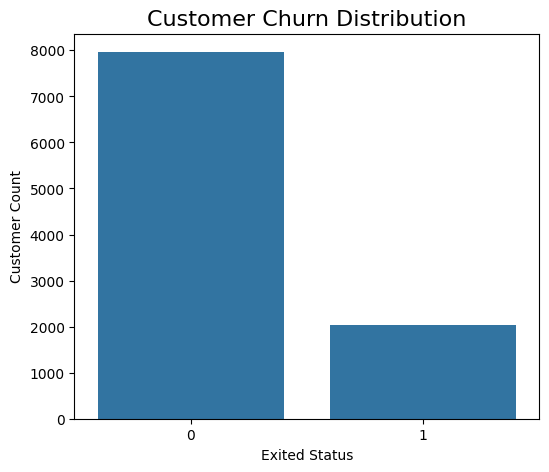

In [25]:
plt.figure(figsize=(6,5))

sns.countplot(x='exited', data=df)

plt.title('Customer Churn Distribution', fontsize=16)
plt.xlabel('Exited Status')
plt.ylabel('Customer Count')

plt.show()

<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> Most customers stayed with the bank, while a smaller percentage exited.
</div>

<h3 style="color:darkgreen;">4.2 Pie Chart – Gender Distribution</h3>

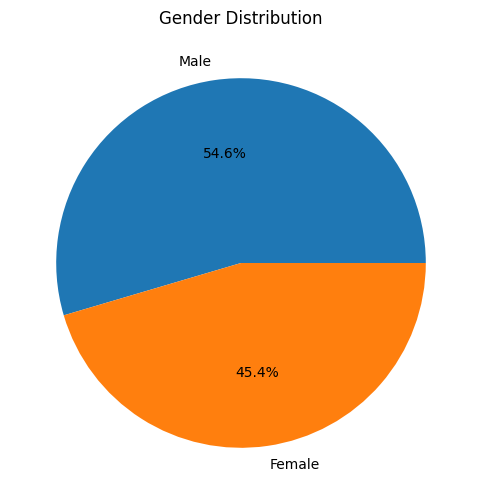

In [26]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)

plt.title('Gender Distribution')

plt.show()

<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> Male customers slightly outnumber female customers in the dataset.
</div>


<h3 style="color:darkgreen;">4.3 Histogram – Age Distribution</h3>

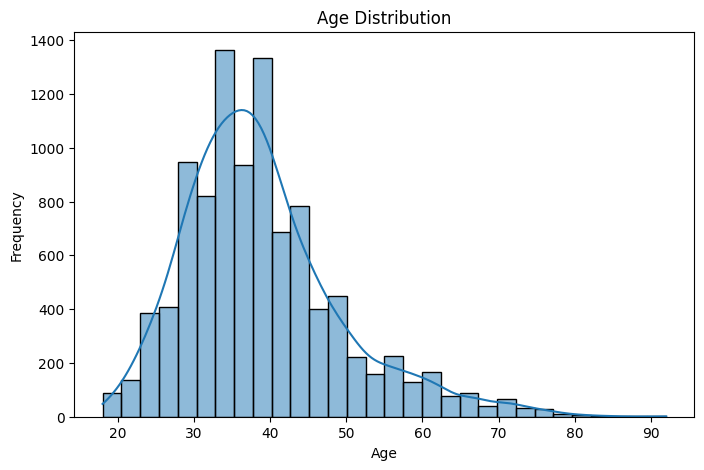

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> Most customers fall between 30 and 45 years of age.
</div>


<h3 style="color:darkgreen;">4.4 Bar Plot - Churn by Gender</h3>

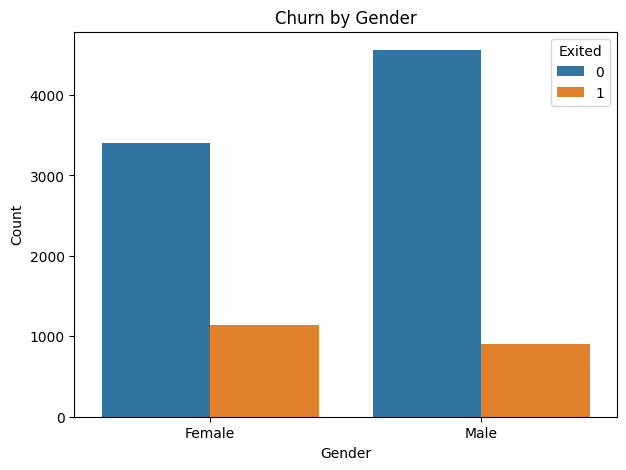

In [39]:
plt.figure(figsize=(7,5))

sns.countplot(x='gender', hue='exited', data=df)

plt.title('Churn by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.legend(title='Exited')

plt.show()

<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> Female customers show a slightly higher churn rate compared to male customers.
    
<b>Interpretation:</b> The bank may need to analyze customer preferences and improve personalized services to better retain female customers.
</div>




<h3 style="color:darkgreen;">4.5 Scatter Plot – Age vs Balance</h3> 

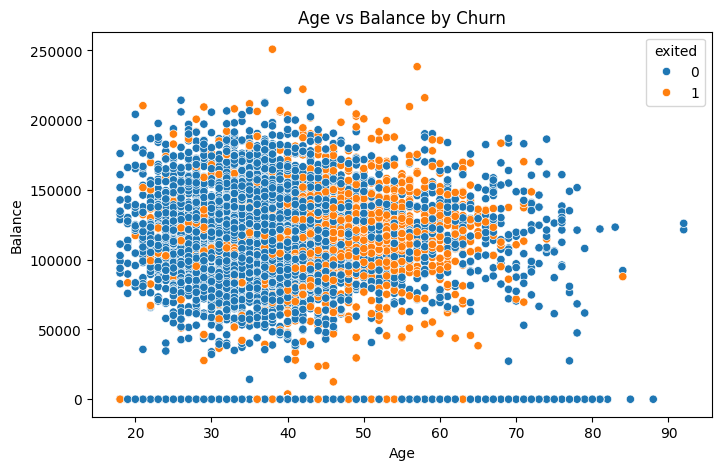

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='age',
    y='balance',
    hue='exited',
    data=df
)

plt.title('Age vs Balance by Churn')
plt.xlabel('Age')
plt.ylabel('Balance')

plt.show()

<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> Older customers with higher balances are more likely to churn.
    
<b>Interpretation:</b> Older customers may be less satisfied with current banking services or may shift to competitors offering better financial products and benefits.
</div>


<h3 style="color:darkgreen;">4.6 Bar Plot - Is Active Member by Churn</h3> 

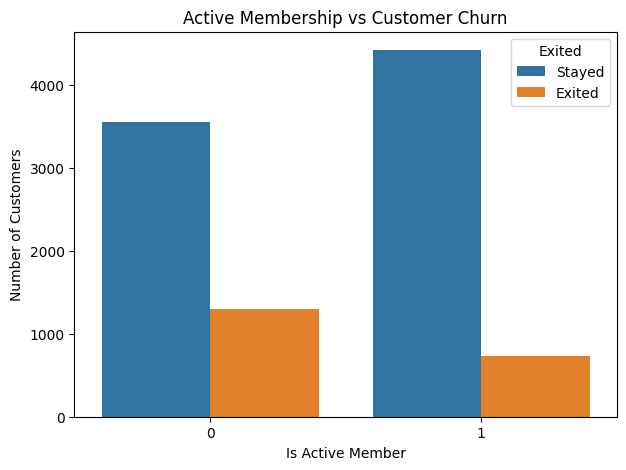

In [41]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='isactivemember',
    hue='exited',
    data=df
)

plt.title('Active Membership vs Customer Churn')
plt.xlabel('Is Active Member')
plt.ylabel('Number of Customers')

plt.legend(title='Exited', labels=['Stayed', 'Exited'])

plt.show()

<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> The visualization shows that inactive customers are more likely to leave the bank compared to active members. Customers who actively use banking services tend to remain loyal, indicating that customer engagement plays a significant role in reducing churn.
    
<b>Interpretation:</b> Increasing customer engagement through:
- mobile banking
- rewards programs
- personalized offers

can improve retention rates.
</div>


<h3 style="color:darkgreen;">4.6 Heatmap – Correlation Matrix</h3>

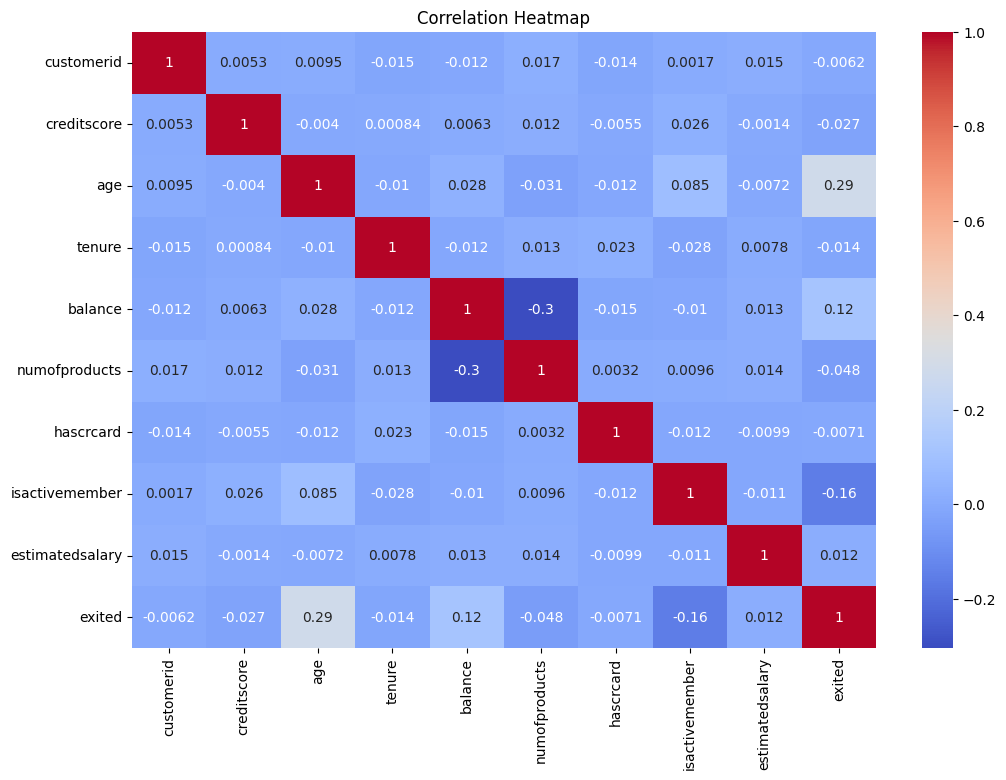

In [30]:
plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> Age and balance show positive correlation with churn, while tenure and active membership negatively relate to churn.
    
<b>Interpretation:</b> Customer engagement and demographic factors appear more influential than credit scores in predicting churn.
</div>



<h3 style="color:darkgreen;">4.7 Count Plot – Geography vs Churn</h3>

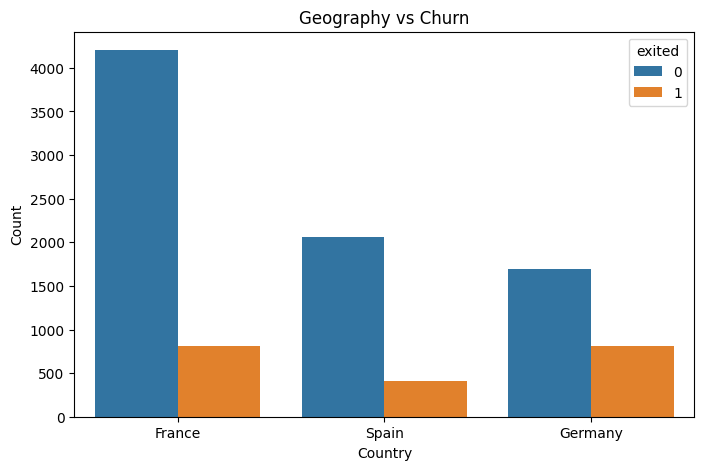

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='geography',
    hue='exited',
    data=df
)

plt.title('Geography vs Churn')
plt.xlabel('Country')
plt.ylabel('Count')

plt.show()

<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> Germany shows a noticeably higher churn rate compared to France and Spain.
    
<b>Interpretation:</b> This may indicate:
- Customer dissatisfaction
- Strong market competition
- Service quality differences in that region

The bank should investigate customer experience specifically in Germany.
</div>


<h3 style="color:darkgreen;">4.8 Line Chart – Average Balance by Tenure</h3>

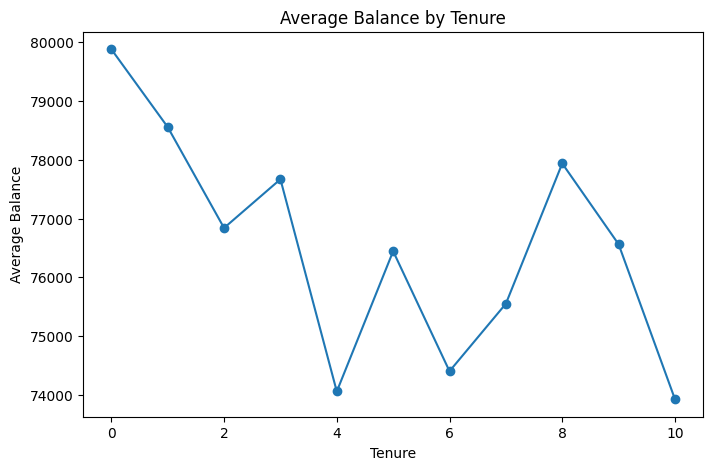

In [32]:
avg_balance = df.groupby('tenure')['balance'].mean()

plt.figure(figsize=(8,5))

plt.plot(avg_balance.index, avg_balance.values, marker='o')

plt.title('Average Balance by Tenure')
plt.xlabel('Tenure')
plt.ylabel('Average Balance')

plt.show()

<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> Customers with higher tenure generally maintain stable or slightly higher balances, indicating stronger long-term engagement with the bank. Fluctuations at certain tenure levels may suggest variations in customer financial behavior and retention patterns.
    
<b>Interpretation:</b> The analysis helps identify whether long-term customers maintain higher balances compared to newer customers.
</div>


<h3 style="color:darkgreen;">4.9 Violin Plot – Age Distribution by Gender</h3>

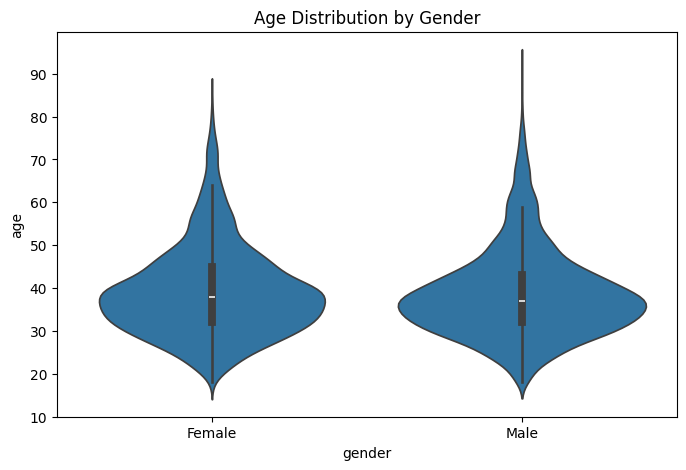

In [33]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='gender',
    y='age',
    data=df
)

plt.title('Age Distribution by Gender')

plt.show()

<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> Both genders have a similar age spread, with most customers concentrated in the middle-age range. Female customers appear to have a slightly wider age distribution, indicating greater variability in customer age compared to male customers.
    
<b>Interpretation:</b> The visualization helps compare not only the average age but also the variability and distribution shape between genders. Since both groups show similar distributions, gender alone may not strongly influence customer age patterns. However, differences in density at certain age ranges could help identify customer segments for targeted banking services or retention strategies.
</div>



<h3 style="color:darkgreen;">4.10 Pair Plot – Multiple Variable Relationships</h3>

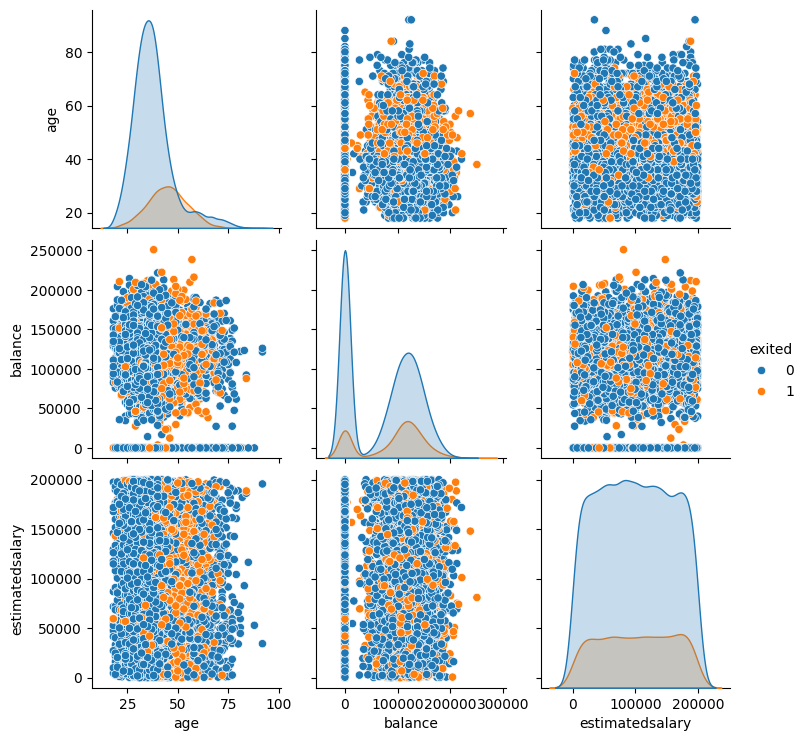

In [34]:
sns.pairplot(
    df[['age', 'balance', 'estimatedsalary', 'exited']],
    hue='exited'
)

plt.show()

<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> The pair plot reveals relationships and patterns among multiple numerical variables such as age, balance and estimated salary. It helps identify trends, clusters, and potential correlations between features. Customers with higher age and balance values appear more associated with churn, while some variables show weak or minimal relationships with each other.
    
<b>Interpretation:</b> High-value customers leaving the bank can significantly affect revenue and profitability.  
This indicates a need for targeted retention strategies for premium customers.
</div>


<h3 style="color:darkgreen;">4.11 Subplots</h3>

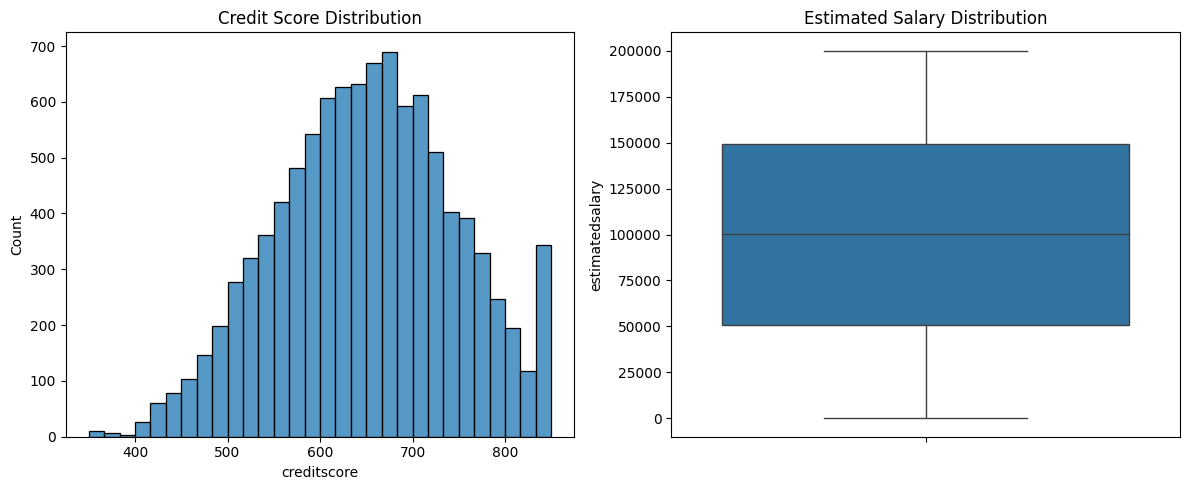

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Histogram
sns.histplot(df['creditscore'], bins=30, ax=axes[0])
axes[0].set_title('Credit Score Distribution')

# Boxplot
sns.boxplot(y='estimatedsalary', data=df, ax=axes[1])
axes[1].set_title('Estimated Salary Distribution')

plt.tight_layout()

plt.show()

<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> The subplot comparison shows that customer credit scores are concentrated within the mid-range values, indicating most customers have moderate creditworthiness. The estimated salary distribution appears relatively uniform, suggesting customers belong to diverse income groups. There is no strong salary concentration in a particular range, while credit scores exhibit a more centralized distribution pattern.
    
<b>Interpretation:</b> The comparison indicates that while customer salaries vary broadly, credit scores remain relatively centered around average values. This suggests that salary alone may not strongly influence credit score distribution or customer churn behavior.
</div>



<h3 style="color:darkgreen;">4.12 Interactive Plotly Visualization</h3>

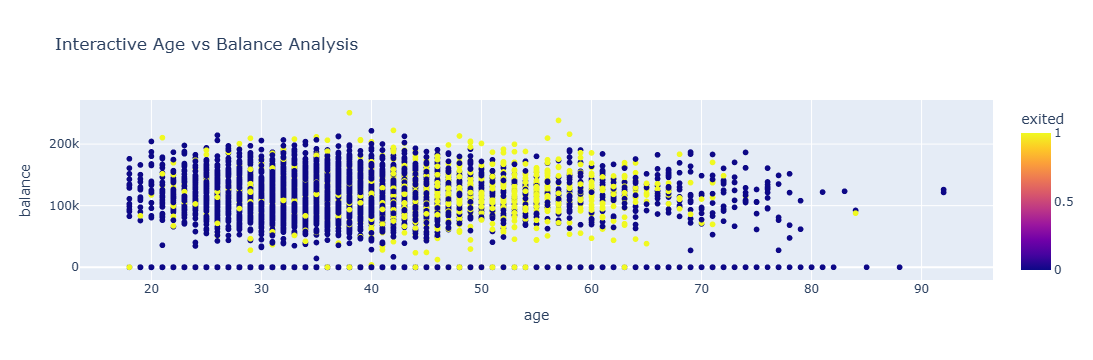

In [36]:
fig = px.scatter(
    df,
    x='age',
    y='balance',
    color='exited',
    title='Interactive Age vs Balance Analysis'
)

fig.show()

<div style="background-color:#e8f4fd; padding:10px; border-radius:5px;">
<b>Insight:</b> The interactive scatter plot highlights the relationship between customer age and account balance. Customers with higher balances are generally concentrated in middle and older age groups. The visualization also indicates that churned customers are more common among older customers with substantial account balances, suggesting that retaining high-value senior customers should be a priority for the bank.
    
<b>Interpretation:</b> 
- Age and balance together influence customer churn behavior.
- Older customers with substantial balances may expect better banking services and are more likely to leave if dissatisfied.
- Customers with low balances are distributed across all age groups but show comparatively lower churn rates.
- The visualization helps identify high-value customers who may require targeted retention strategies.
</div>


<div style="background-color:#D6F7B7; padding:10px; border-radius:5px;">
<b>Anomalies and Observations</b>

- Some customers maintain zero account balances but still remain active.
- A few customers with very high salaries also exited the bank.
- Tenure alone does not strongly determine customer retention.

These patterns suggest churn behavior depends on multiple combined factors.

---

<b>Overall Conclusion</b>

This exploratory analysis successfully identified major factors affecting customer churn in the bank.

Key drivers of churn include:
- Age
- Geography
- Account balance
- Customer activity status

The analysis highlights that customer engagement and regional performance play important roles in retention.

---

<b>Recommendations</b>

<b>1. Improve Customer Retention Programs</b>

Create loyalty and rewards programs for high-risk customers.

<b>2. Focus on High-Balance Customers</b>

Provide personalized financial services and premium support.

<b>3. Increase Customer Engagement</b>

Encourage customers to actively use banking services and digital platforms.

<b>4. Investigate Regional Issues</b>

Conduct detailed analysis of customer dissatisfaction in Germany.

<b>5. Build Predictive Models</b>

Use machine learning techniques to predict churn early and take preventive action.

---

<b>Final Summary</b>

The project demonstrates how data analysis and visualization can help banks understand customer behavior and improve business decision-making.  
The findings can support strategic planning, improve customer satisfaction, and reduce future customer attrition.
</div>